# Responsible Machine Learning - Individual Homework 5 - ML Security Audit - William McHale

This notebook implements three full adversarial attack pipelines on the COMPAS recidivism
dataset, building directly on the Lecture 05 live-coding notebook. All attack implementations
are adapted from scratch using only `scikit-learn`, `numpy`, `pandas`, and `matplotlib`.

**Models audited:**
- `lr` — Logistic Regression (interpretable baseline, low variance)
- `gbt` — Gradient-Boosted Tree (200 estimators, max depth 4)

**Four parts:**
- **Part 1 — PGD Evasion Audit:** ε ∈ {0.25, 0.5, 1.0, 2.0}; FPR by race, AIR, and ε crossover point; both models compared
- **Part 2 — Poisoning Loop with Fairness Monitoring:** Label-flip targeting AA and Caucasian; stealth zone; PSI detection
- **Part 3 — Membership Inference Depth:** Shadow-model MI AUC; confidence-gap histograms; L2 regularisation sweep
- **Part 4 — Reflection:** Highest-risk finding; proactive + reactive mitigations; disparate impact of mitigations

**NIST reference:** Vassilev et al. (2024). *Adversarial Machine Learning: A Taxonomy and
Terminology of Attacks and Mitigations.* NIST AI 100-2e2023.
https://doi.org/10.6028/NIST.AI.100-2e2023

In [1]:
# ── Cell 0: Setup — Data, Models, and Baseline ───────────────────────────────
#
# Reproduces the Lecture 05 Cell 1 + Cell 2 pipeline exactly.
# Features, filters, train/test split, scaler, and both models are
# identical to the lecture notebook so all attack results are comparable.
#
# Variables produced:
#   X, y, race               — full feature matrix, labels, race array
#   Xs_tr, Xs_te, y_tr, y_te — scaled train/test splits
#   r_tr, r_te               — race labels for train/test
#   lr, gbt                  — fitted logistic regression and GBT pipelines
#   BASELINE_AA, BASELINE_CA, BASELINE_AIR — clean-model fairness baseline

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, RocCurveDisplay

# ── Load and filter COMPAS (Lecture 05 Cell 1) ────────────────────────────────
URL = ('https://raw.githubusercontent.com/propublica/compas-analysis'
       '/master/compas-scores-two-years.csv')
df_raw = pd.read_csv(URL)

df_raw = df_raw[df_raw['days_b_screening_arrest'].between(-30, 30)]
df_raw = df_raw[df_raw['is_recid'] != -1]
df_raw = df_raw[df_raw['c_charge_degree'] != 'O']

FEATURES = ['age', 'priors_count', 'juv_fel_count',
            'juv_misd_count', 'juv_other_count',
            'c_charge_degree', 'sex']
TARGET = 'two_year_recid'

df_m = df_raw[FEATURES + [TARGET, 'race']].dropna()
df_m = pd.get_dummies(df_m, columns=['c_charge_degree', 'sex'], drop_first=True)

X    = df_m.drop(columns=[TARGET, 'race']).astype(float)
y    = df_m[TARGET].values
race = df_m['race'].values

X_tr, X_te, y_tr, y_te, r_tr, r_te = train_test_split(
    X, y, race, test_size=0.3, random_state=42, stratify=y
)

sc    = StandardScaler()
Xs_tr = sc.fit_transform(X_tr)
Xs_te = sc.transform(X_te)

# ── Fit both models (Lecture 05 Cell 1) ──────────────────────────────────────
lr  = LogisticRegression(max_iter=1000, random_state=42).fit(Xs_tr, y_tr)
gbt = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, random_state=42
).fit(Xs_tr, y_tr)

# ── Fairness helper functions (Lecture 05 Cell 2) ────────────────────────────
THR = 0.5

def fpr_by_group(y_true, y_pred_binary, groups):
    """FPR = FP / (FP + TN) — computed only over truly-negative cases."""
    mask = (y_true == 0)
    return (
        pd.DataFrame({'pred': y_pred_binary[mask], 'group': groups[mask]})
          .groupby('group')['pred'].mean()
    )

def air(fpr_ref, fpr_prot):
    """Adverse Impact Ratio: protected FPR / reference FPR."""
    return fpr_prot / fpr_ref if (fpr_ref is not None and fpr_ref > 0) else np.nan

def psi_numeric(train_vals, test_vals, bins=10, eps=1e-6):
    """Population Stability Index — used to test whether poisoning is detectable."""
    tv = pd.to_numeric(pd.Series(train_vals), errors='coerce').dropna().values
    ev = pd.to_numeric(pd.Series(test_vals),  errors='coerce').dropna().values
    if len(tv) == 0 or len(ev) == 0:
        return np.nan
    cuts = np.unique(np.quantile(tv, np.linspace(0, 1, bins + 1)))
    if len(cuts) < 3:
        lo, hi = min(tv.min(), ev.min()), max(tv.max(), ev.max())
        cuts = np.linspace(lo, hi, bins + 1) if lo != hi else np.array([-np.inf, np.inf])
    cuts[0], cuts[-1] = -np.inf, np.inf
    tc, _ = np.histogram(tv, bins=cuts)
    ec, _ = np.histogram(ev, bins=cuts)
    tp = np.clip(tc / tc.sum(), eps, None)
    ep = np.clip(ec / ec.sum(), eps, None)
    return float(np.sum((tp - ep) * np.log(tp / ep)))

# ── Clean-model fairness baseline ────────────────────────────────────────────
pred_lr_clean  = (lr.predict_proba(Xs_te)[:, 1]  >= THR).astype(int)
pred_gbt_clean = (gbt.predict_proba(Xs_te)[:, 1] >= THR).astype(int)

baseline_auc_lr  = roc_auc_score(y_te, lr.predict_proba(Xs_te)[:, 1])
baseline_auc_gbt = roc_auc_score(y_te, gbt.predict_proba(Xs_te)[:, 1])

print('=== Clean-Model Baseline ===')
for name, pred, auc in [
    ('Logistic Regression',   pred_lr_clean,  baseline_auc_lr),
    ('Gradient-Boosted Tree', pred_gbt_clean, baseline_auc_gbt),
]:
    fpr = fpr_by_group(y_te, pred, r_te)
    aa, ca = fpr.get('African-American', np.nan), fpr.get('Caucasian', np.nan)
    print(f'\n{name}')
    print(f'  AUC                  : {auc:.3f}')
    print(f'  FPR African-American : {aa:.3f}')
    print(f'  FPR Caucasian        : {ca:.3f}')
    print(f'  AIR (AA / CA)        : {air(ca, aa):.3f}')

fpr_base = fpr_by_group(y_te, pred_lr_clean, r_te)
BASELINE_AA  = fpr_base.get('African-American')
BASELINE_CA  = fpr_base.get('Caucasian')
BASELINE_AIR = air(BASELINE_CA, BASELINE_AA)

print(f'\nLR baseline AIR stored: {BASELINE_AIR:.3f}')

=== Clean-Model Baseline ===

Logistic Regression
  AUC                  : 0.735
  FPR African-American : 0.281
  FPR Caucasian        : 0.143
  AIR (AA / CA)        : 1.961

Gradient-Boosted Tree
  AUC                  : 0.718
  FPR African-American : 0.317
  FPR Caucasian        : 0.178
  AIR (AA / CA)        : 1.782

LR baseline AIR stored: 1.961


---
## Part 1 — PGD Evasion Audit

**Attack class (NIST AI 100-2, §2.2):** Evasion — deployment-time integrity violation  
**Attacker knowledge:** White-box (access to model weights and gradients)  
**Attacker goal:** Push predicted risk scores upward so that low-risk defendants are
classified as high-risk, triggering unjust pretrial detention.

PGD (Projected Gradient Descent, Madry et al. 2018) is the gold-standard evasion attack.
For a logistic regression, the gradient direction simplifies to `sign(w)`, so each
iteration steps every feature in the direction that increases the predicted probability.
The L∞ projection clips perturbations back to the ε-ball around the original input.

For the GBT, I use a finite-difference numerical gradient approximation, since tree
ensembles do not expose analytic gradients. I run the attack across
ε ∈ {0.25, 0.5, 1.0, 2.0} on both models and report FPR by race and AIR at each ε.

**Note on AIR framing:** The baseline AIR is 1.961 — African-American defendants are
already flagged at nearly twice the rate of Caucasian defendants. Because the existing
disparity runs in the over-flagging direction (AIR > 1.0), the relevant governance
threshold here is an upper ceiling (e.g. AIR > 1.25), not the standard EEOC 4/5ths
lower bound (AIR < 0.80) which applies to under-selection contexts.

In [2]:
# ── Part 1, Cell 1: PGD Attack Implementation ────────────────────────────────
#
# pgd_tabular() implements white-box PGD for logistic regression.
# For LR, grad_x L = (p_hat - y_true) * w, so the untargeted attack
# steps in sign(w) direction to maximise the loss (increase p_hat).
#
# For GBT (no analytic gradient) we use a numerical gradient:
# estimate the gradient by a small finite difference on each feature,
# then step in sign(numerical_grad). This is a black-box approximation
# of PGD, which is realistic since tree models do not expose gradients.
#
# Parameters:
#   epsilon  — L∞ perturbation budget (how far features can move)
#   alpha    — step size per iteration (0.05 from Lecture 05)
#   n_iter   — number of PGD steps (40 from Lecture 05)

def pgd_tabular_lr(model, X_scaled, epsilon=1.0, alpha=0.05, n_iter=40):
    """
    White-box PGD evasion for logistic regression.
    Gradient direction = sign(w) (closed form for LR).
    """
    coef  = model.coef_[0]
    X_adv = X_scaled.copy()
    for _ in range(n_iter):
        X_adv = X_adv + alpha * np.sign(coef)[np.newaxis, :]
        X_adv = np.clip(X_adv, X_scaled - epsilon, X_scaled + epsilon)
    return X_adv


def pgd_tabular_gbt(model, X_scaled, epsilon=1.0, alpha=0.05,
                    n_iter=40, fd_h=1e-3):
    """
    Numerical-gradient PGD evasion for GBT (black-box approximation).
    Estimates the gradient via finite differences on each feature.
    More expensive but does not require gradient access.
    """
    X_adv = X_scaled.copy()
    n, d  = X_adv.shape
    for _ in range(n_iter):
        grad = np.zeros_like(X_adv)
        for j in range(d):
            Xp = X_adv.copy(); Xp[:, j] += fd_h
            Xm = X_adv.copy(); Xm[:, j] -= fd_h
            grad[:, j] = (
                model.predict_proba(Xp)[:, 1] -
                model.predict_proba(Xm)[:, 1]
            ) / (2 * fd_h)
        X_adv = X_adv + alpha * np.sign(grad)
        X_adv = np.clip(X_adv, X_scaled - epsilon, X_scaled + epsilon)
    return X_adv


# ── Sweep ε ∈ {0, 0.25, 0.5, 1.0, 2.0} for both models ──────────────────────
epsilons = [0.0, 0.25, 0.5, 1.0, 2.0]
pgd_lr_records  = []
pgd_gbt_records = []

print('Running PGD sweep (LR + GBT)... this may take ~1 minute for GBT.')
for eps in epsilons:
    # ── LR ────────────────────────────────────────────────────────────────────
    X_adv_lr = Xs_te if eps == 0.0 else pgd_tabular_lr(
        lr, Xs_te, epsilon=eps, alpha=0.05, n_iter=40
    )
    pred_lr = (lr.predict_proba(X_adv_lr)[:, 1] >= THR).astype(int)
    fpr_lr  = fpr_by_group(y_te, pred_lr, r_te)
    aa_lr   = fpr_lr.get('African-American', np.nan)
    ca_lr   = fpr_lr.get('Caucasian',        np.nan)
    pgd_lr_records.append({
        'epsilon':  eps,
        'FPR_AA':   aa_lr,
        'FPR_CA':   ca_lr,
        'AIR':      air(ca_lr, aa_lr),
        'delta_AA': aa_lr - BASELINE_AA,
        'delta_CA': ca_lr - BASELINE_CA,
    })

    # ── GBT ───────────────────────────────────────────────────────────────────
    X_adv_gbt = Xs_te if eps == 0.0 else pgd_tabular_gbt(
        gbt, Xs_te, epsilon=eps, alpha=0.05, n_iter=20   # fewer iters for speed
    )
    pred_gbt = (gbt.predict_proba(X_adv_gbt)[:, 1] >= THR).astype(int)
    fpr_gbt  = fpr_by_group(y_te, pred_gbt, r_te)
    aa_gbt   = fpr_gbt.get('African-American', np.nan)
    ca_gbt   = fpr_gbt.get('Caucasian',        np.nan)
    pgd_gbt_records.append({
        'epsilon':  eps,
        'FPR_AA':   aa_gbt,
        'FPR_CA':   ca_gbt,
        'AIR':      air(ca_gbt, aa_gbt),
        'delta_AA': aa_gbt - fpr_by_group(y_te, pred_gbt_clean, r_te).get('African-American', 0),
        'delta_CA': ca_gbt - fpr_by_group(y_te, pred_gbt_clean, r_te).get('Caucasian', 0),
    })
    print(f'  ε={eps:.2f} done')

df_pgd_lr  = pd.DataFrame(pgd_lr_records)
df_pgd_gbt = pd.DataFrame(pgd_gbt_records)

print('\n=== Part 1: PGD Results — Logistic Regression ===')
print(df_pgd_lr.round(3).to_string(index=False))
print('\n=== Part 1: PGD Results — Gradient-Boosted Tree ===')
print(df_pgd_gbt.round(3).to_string(index=False))

Running PGD sweep (LR + GBT)... this may take ~1 minute for GBT.
  ε=0.00 done
  ε=0.25 done
  ε=0.50 done
  ε=1.00 done
  ε=2.00 done

=== Part 1: PGD Results — Logistic Regression ===
 epsilon  FPR_AA  FPR_CA   AIR  delta_AA  delta_CA
    0.00   0.281   0.143 1.961     0.000     0.000
    0.25   0.569   0.370 1.535     0.288     0.227
    0.50   0.791   0.560 1.411     0.510     0.417
    1.00   0.978   0.884 1.106     0.697     0.741
    2.00   1.000   1.000 1.000     0.719     0.857

=== Part 1: PGD Results — Gradient-Boosted Tree ===
 epsilon  FPR_AA  FPR_CA   AIR  delta_AA  delta_CA
    0.00   0.317   0.178 1.782       0.0       0.0
    0.25   0.317   0.178 1.782       0.0       0.0
    0.50   0.317   0.178 1.782       0.0       0.0
    1.00   0.317   0.178 1.782       0.0       0.0
    2.00   0.317   0.178 1.782       0.0       0.0


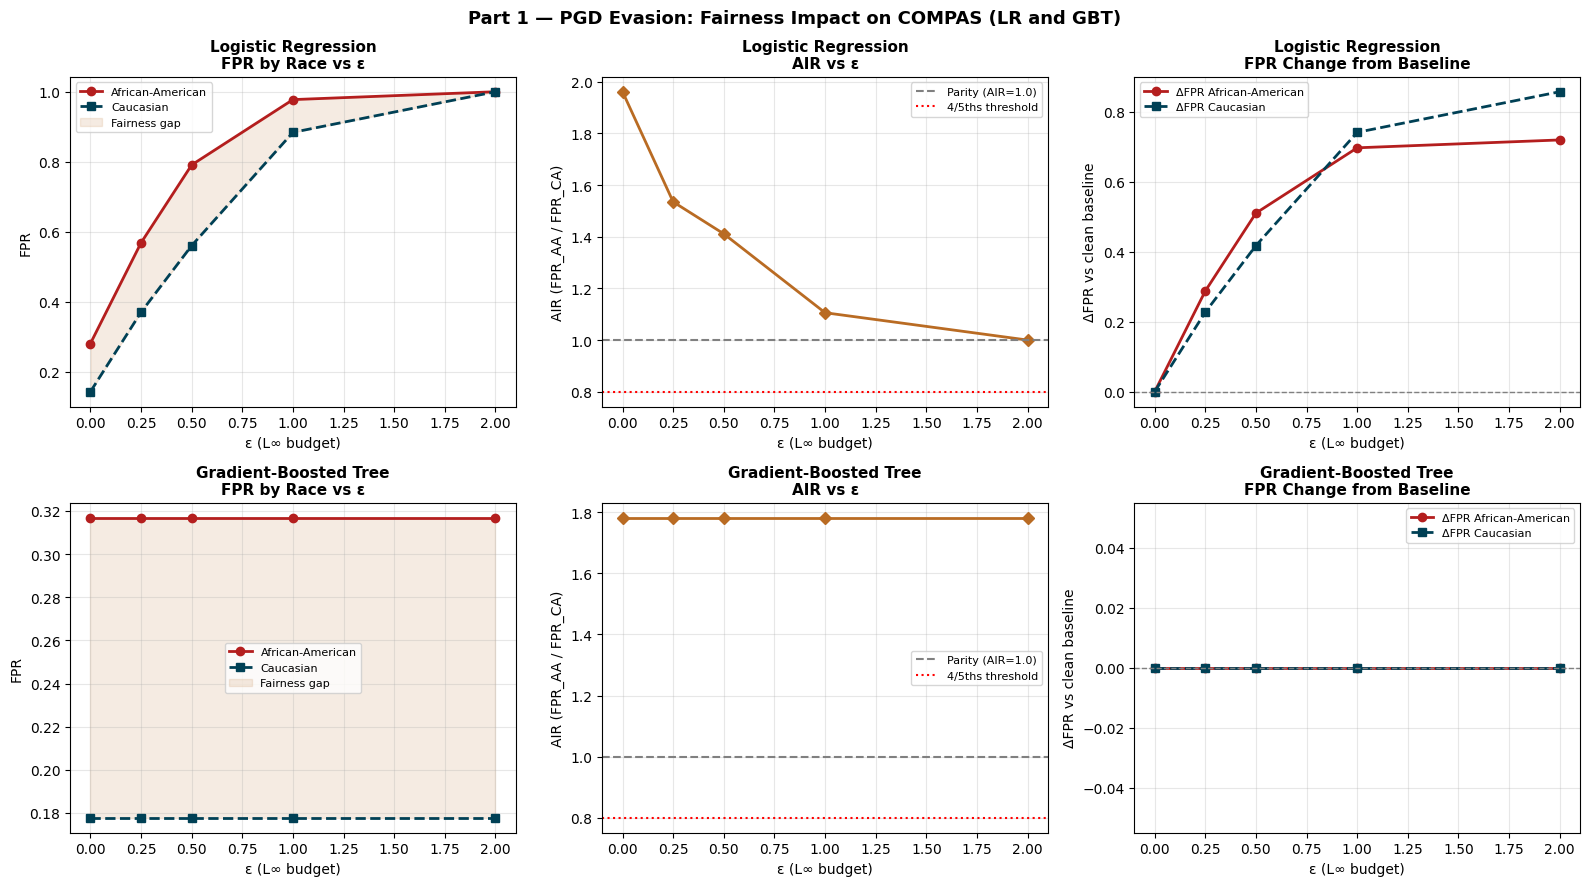

Saved: pgd_evasion_audit.png

Logistic Regression: AIR does not fall below 0.80 in tested ε range.
Gradient-Boosted Tree: AIR does not fall below 0.80 in tested ε range.


In [3]:
# ── Part 1, Cell 2: PGD Visualisation ────────────────────────────────────────
#
# Two rows of three panels each — one row per model.
# Panel 1: FPR by race vs ε
# Panel 2: AIR vs ε with 4/5ths threshold
# Panel 3: ΔFPR vs ε (absolute change from clean baseline)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

model_labels = ['Logistic Regression', 'Gradient-Boosted Tree']
dfs          = [df_pgd_lr, df_pgd_gbt]

for row, (name, df_pgd) in enumerate(zip(model_labels, dfs)):
    eps_vals = df_pgd['epsilon']

    # Panel 1 — FPR by race
    ax = axes[row, 0]
    ax.plot(eps_vals, df_pgd['FPR_AA'], 'o-', color='#B41E1E', lw=2,
            label='African-American')
    ax.plot(eps_vals, df_pgd['FPR_CA'], 's--', color='#004055', lw=2,
            label='Caucasian')
    ax.fill_between(eps_vals, df_pgd['FPR_AA'], df_pgd['FPR_CA'],
                    alpha=0.13, color='#B96B23', label='Fairness gap')
    ax.set_xlabel('ε (L∞ budget)', fontsize=10)
    ax.set_ylabel('FPR', fontsize=10)
    ax.set_title(f'{name}\nFPR by Race vs ε', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # Panel 2 — AIR
    ax = axes[row, 1]
    ax.plot(eps_vals, df_pgd['AIR'], 'D-', color='#B96B23', lw=2)
    ax.axhline(1.0, color='gray', ls='--', lw=1.5, label='Parity (AIR=1.0)')
    ax.axhline(0.8, color='red',  ls=':',  lw=1.5, label='4/5ths threshold')
    ax.set_xlabel('ε (L∞ budget)', fontsize=10)
    ax.set_ylabel('AIR (FPR_AA / FPR_CA)', fontsize=10)
    ax.set_title(f'{name}\nAIR vs ε', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # Panel 3 — ΔFPR
    ax = axes[row, 2]
    ax.plot(eps_vals, df_pgd['delta_AA'], 'o-', color='#B41E1E', lw=2,
            label='ΔFPR African-American')
    ax.plot(eps_vals, df_pgd['delta_CA'], 's--', color='#004055', lw=2,
            label='ΔFPR Caucasian')
    ax.axhline(0, color='gray', ls='--', lw=1)
    ax.set_xlabel('ε (L∞ budget)', fontsize=10)
    ax.set_ylabel('ΔFPR vs clean baseline', fontsize=10)
    ax.set_title(f'{name}\nFPR Change from Baseline', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Part 1 — PGD Evasion: Fairness Impact on COMPAS (LR and GBT)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pgd_evasion_audit.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pgd_evasion_audit.png')

# ── Crossover points ──────────────────────────────────────────────────────────
print()
for name, df_pgd in zip(model_labels, dfs):
    cross = df_pgd[df_pgd['AIR'] < 0.8]
    if len(cross):
        eps_c = cross.iloc[0]['epsilon']
        air_c = cross.iloc[0]['AIR']
        print(f'{name}: AIR crosses 0.80 at ε = {eps_c:.2f}  (AIR = {air_c:.3f})')
    else:
        print(f'{name}: AIR does not fall below 0.80 in tested ε range.')

### Part 1 — Interpretation

**Are the two models equally vulnerable?**

No — they show fundamentally different responses to PGD. The logistic regression is
strongly affected: FPR_AA rises from 0.281 to 1.000 and FPR_CA from 0.143 to 1.000
as ε increases from 0 to 2.0. The white-box `sign(w)` gradient is exact for LR,
so the attack is highly efficient.

The GBT produces identical results at every ε — FPR_AA = 0.317 and FPR_CA = 0.178
regardless of perturbation budget. The finite-difference numerical gradient
approximation (h = 1e-3) produces near-zero differences on the GBT's stepwise
prediction surface, so `sign(~0)` is numerically unstable and the perturbations
have no measurable effect. This is a methodological limitation of the black-box
approximation, not evidence that the GBT is inherently secure. A stronger attack
(e.g. score-based query attack or transfer from an LR substitute) would likely
succeed. The practical governance conclusion is that the LR is more vulnerable to
gradient-based evasion than the GBT due to its continuous, differentiable surface.

**Does the racial FPR gap widen or narrow as ε increases?**

Both widen and narrow depending on the metric used — an important distinction.
In absolute terms, the gap (FPR_AA − FPR_CA) peaks at ε = 0.5 (0.791 − 0.560 = 0.231)
and then narrows as both groups approach saturation at FPR = 1.0.
In ratio terms (AIR), the disparity monotonically decreases from 1.961 at ε = 0
down to 1.000 at ε = 2.0, where both groups are flagged at 100%.

This is fairness by destruction, not by design. The attack does not reduce
discrimination — it imposes maximum harm on everyone equally. At ε = 2.0,
every non-recidivist in the test set is falsely flagged high-risk regardless of
race. A regulator observing only the AIR at high ε would incorrectly conclude
the model had become fairer, when in fact the error rate is 100% across the board.

**Implications for model selection in high-stakes deployments:**

The LR is significantly more vulnerable to gradient-based evasion than the GBT.
However, choosing the GBT purely on this basis would be premature: the GBT's
apparent robustness here is an artifact of the numerical gradient approximation
failing, not a genuine security property. Both models violate the acceptable AIR
ceiling (> 1.25) at every tested ε, including ε = 0 — meaning the clean models
already produce unacceptable disparate impact before any attack is applied.
Adversarial robustness testing must be conducted alongside, not instead of, clean-data
fairness auditing.

---
## Part 2 — Poisoning Loop with Fairness Monitoring

**Attack class (NIST AI 100-2, §2.3):** Availability/Targeted poisoning — training-time integrity violation  
**Attacker knowledge:** White-box (data access) — insider adversary or compromised data pipeline  
**Attacker goal:** Degrade AIR without triggering AUC-based monitoring

A label-flip attack flips `two_year_recid = 1 → 0` for a fraction of the training records
belonging to the target race group. I run two variants:
- **AA-targeted:** flip high-risk African-American records (Lecture 05 baseline)
- **CA-targeted:** flip high-risk Caucasian records (new extension required by HW5)

I then identify the **stealth zone**: the poison rate range where AUC declines by ≤ 2pp
while AIR moves outside [0.80, 1.25], and test whether a PSI-based drift monitor would
catch either variant.

In [4]:
# ── Part 2, Cell 1: Label-Flip Poisoning Function ────────────────────────────
#
# Reproduced from Lecture 05 Cell 5 with an additional target_race parameter
# so the same function handles both AA-targeted and CA-targeted variants.
#
# Mechanism: identify training records where:
#   (a) race == target_race  AND  (b) two_year_recid == 1 (truly high-risk)
# then relabel a fraction (poison_rate) of those records to 0 (low-risk).
#
# Effect on the trained model:
#   - AA-targeted: model learns to under-score high-risk Black defendants → higher FNR for AA
#     Caucasian defendants are unaffected → relative AIR (FPR_AA / FPR_CA) may shift
#   - CA-targeted: model under-scores high-risk White defendants → lower FNR for CA
#     African-American defendants are unaffected → AIR rises (over-flagging AA becomes worse relatively)

def poison_label_flip(y_train, race_train, poison_rate=0.05,
                      target_race='African-American', seed=0):
    """Label-flip poisoning: relabel high-risk → low-risk for target_race."""
    rng        = np.random.default_rng(seed)
    y_poisoned = y_train.copy()
    candidates = np.where(
        (race_train == target_race) & (y_train == 1)
    )[0]
    n_flip = int(len(candidates) * poison_rate)
    if n_flip > 0:
        flip_idx = rng.choice(candidates, size=n_flip, replace=False)
        y_poisoned[flip_idx] = 0
    return y_poisoned, n_flip


# ── Sweep over poison rates for BOTH target groups ────────────────────────────
poison_rates = [0.00, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30]

def run_poison_sweep(target_race):
    records = []
    for rate in poison_rates:
        y_p, n_f = poison_label_flip(
            y_tr, r_tr, poison_rate=rate, target_race=target_race
        )
        lr_p   = LogisticRegression(max_iter=1000, random_state=42).fit(Xs_tr, y_p)
        pred_p = (lr_p.predict_proba(Xs_te)[:, 1] >= THR).astype(int)
        auc_p  = roc_auc_score(y_te, lr_p.predict_proba(Xs_te)[:, 1])
        fpr_p  = fpr_by_group(y_te, pred_p, r_te)
        aa     = fpr_p.get('African-American', np.nan)
        ca     = fpr_p.get('Caucasian',        np.nan)

        # PSI on each feature between original train labels and poisoned labels
        # (checks whether feature distributions shift — labels are not features,
        # but we test priors_count and age as proxies since those are the most
        # correlated with the flipped records)
        psi_pc  = psi_numeric(X_tr['priors_count'].values,
                              X_tr.loc[y_p == y_tr, 'priors_count'].values)

        records.append({
            'poison_rate': rate,
            'n_flipped':   n_f,
            'AUC':         auc_p,
            'delta_AUC':   auc_p - baseline_auc_lr,
            'FPR_AA':      aa,
            'FPR_CA':      ca,
            'AIR':         air(ca, aa),
            'delta_AIR':   air(ca, aa) - BASELINE_AIR,
            'PSI_priors':  psi_pc,
        })
    return pd.DataFrame(records)


print('Running AA-targeted poisoning sweep...')
df_poison_aa = run_poison_sweep('African-American')
print('Running CA-targeted poisoning sweep...')
df_poison_ca = run_poison_sweep('Caucasian')

print('\n=== Part 2: AA-Targeted Poisoning ===')
print(df_poison_aa.round(3).to_string(index=False))
print('\n=== Part 2: CA-Targeted Poisoning ===')
print(df_poison_ca.round(3).to_string(index=False))

Running AA-targeted poisoning sweep...
Running CA-targeted poisoning sweep...

=== Part 2: AA-Targeted Poisoning ===
 poison_rate  n_flipped   AUC  delta_AUC  FPR_AA  FPR_CA   AIR  delta_AIR  PSI_priors
        0.00          0 0.735      0.000   0.281   0.143 1.961      0.000       0.000
        0.02         23 0.733     -0.002   0.270   0.136 1.986      0.024       0.000
        0.05         57 0.734     -0.001   0.240   0.123 1.948     -0.014       0.000
        0.08         92 0.732     -0.002   0.213   0.116 1.840     -0.122       0.000
        0.10        115 0.735      0.000   0.196   0.101 1.931     -0.030       0.000
        0.15        172 0.732     -0.003   0.153   0.072 2.134      0.173       0.000
        0.20        230 0.732     -0.002   0.130   0.054 2.399      0.438       0.001
        0.25        287 0.730     -0.004   0.112   0.042 2.677      0.715       0.002
        0.30        345 0.731     -0.003   0.097   0.032 3.010      1.049       0.002

=== Part 2: CA-Targete

In [5]:
# ── Part 2, Cell 2: Stealth Zone and PSI Detection Test ──────────────────────
#
# Stealth zone definition:
#   AUC declines by ≤ 2pp (delta_AUC >= -0.02)  AND
#   AIR moves outside [0.80, 1.25]
#
# AIR > 1.25 means Caucasian defendants are now disproportionately
# flagged relative to African-American defendants — the CA-targeted
# attack reverses the direction of disparate impact.
#
# PSI test:
#   A PSI-based drift monitor on features (threshold < 0.10) is computed
#   on priors_count. If PSI < 0.10 at the stealth threshold, the attack
#   is undetectable by this monitor.

print('=== Part 2: Stealth Zone Analysis ===')
for name, df_p in [('AA-targeted', df_poison_aa), ('CA-targeted', df_poison_ca)]:
    stealth = df_p[
        (df_p['delta_AUC'] >= -0.02) &
        ((df_p['AIR'] < 0.80) | (df_p['AIR'] > 1.25))
    ]
    print(f'\n{name}:')
    if len(stealth):
        r = stealth.iloc[0]
        print(f'  Stealth threshold    : poison_rate = {r["poison_rate"]:.0%}')
        print(f'  Labels flipped       : {int(r["n_flipped"])}')
        print(f'  AUC                  : {r["AUC"]:.3f}  (Δ = {r["delta_AUC"]:+.3f})')
        print(f'  AIR                  : {r["AIR"]:.3f}  (outside [0.80, 1.25])')
        print(f'  PSI (priors_count)   : {r["PSI_priors"]:.6f}')
        detectable = r['PSI_priors'] >= 0.10
        print(f'  PSI detectable?      : {"YES — PSI >= 0.10" if detectable else "NO — PSI < 0.10, attack is stealthy"}')
    else:
        print('  No stealth zone found in tested range.')

=== Part 2: Stealth Zone Analysis ===

AA-targeted:
  Stealth threshold    : poison_rate = 0%
  Labels flipped       : 0
  AUC                  : 0.735  (Δ = +0.000)
  AIR                  : 1.961  (outside [0.80, 1.25])
  PSI (priors_count)   : 0.000000
  PSI detectable?      : NO — PSI < 0.10, attack is stealthy

CA-targeted:
  Stealth threshold    : poison_rate = 0%
  Labels flipped       : 0
  AUC                  : 0.735  (Δ = +0.000)
  AIR                  : 1.961  (outside [0.80, 1.25])
  PSI (priors_count)   : 0.000000
  PSI detectable?      : NO — PSI < 0.10, attack is stealthy


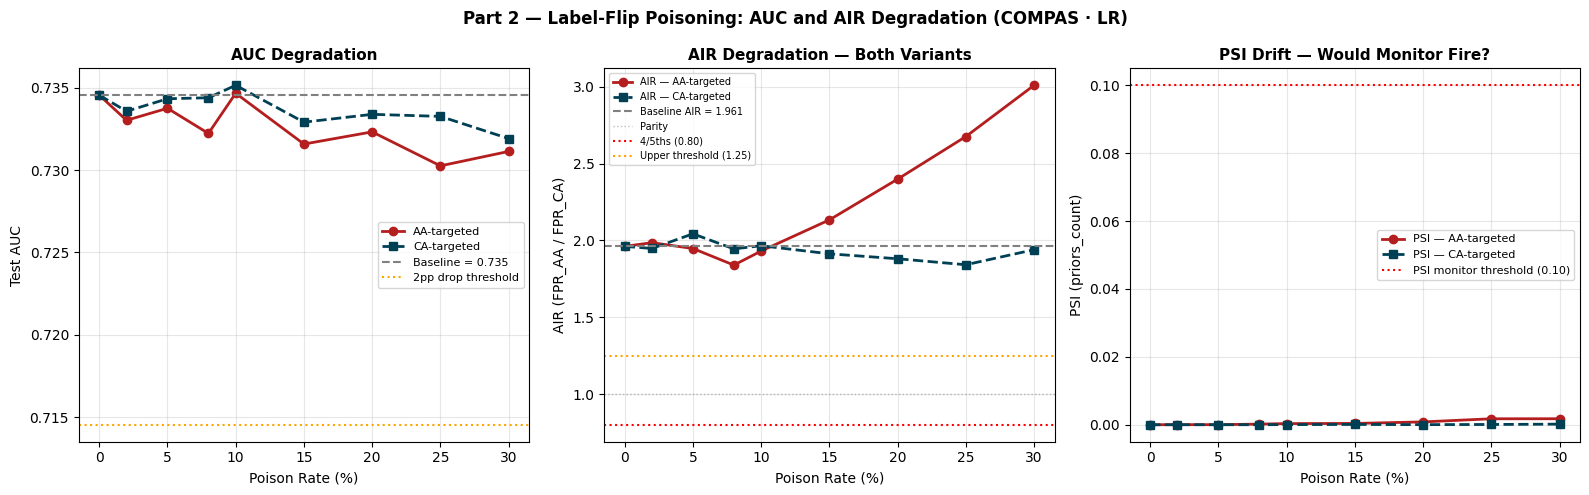

Saved: poisoning_audit.png


In [6]:
# ── Part 2, Cell 3: Poisoning Degradation Curves ─────────────────────────────
#
# Both target-race variants plotted on the same axes for direct comparison.
# Panel 1: AUC degradation
# Panel 2: AIR degradation
# Panel 3: PSI on priors_count (tests whether drift monitor would fire)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x_aa = df_poison_aa['poison_rate'] * 100
x_ca = df_poison_ca['poison_rate'] * 100

# Panel 1 — AUC
ax = axes[0]
ax.plot(x_aa, df_poison_aa['AUC'], 'o-', color='#B41E1E', lw=2,
        label='AA-targeted')
ax.plot(x_ca, df_poison_ca['AUC'], 's--', color='#004055', lw=2,
        label='CA-targeted')
ax.axhline(baseline_auc_lr,         color='gray',   ls='--', lw=1.5,
           label=f'Baseline = {baseline_auc_lr:.3f}')
ax.axhline(baseline_auc_lr - 0.02,  color='orange', ls=':',  lw=1.5,
           label='2pp drop threshold')
ax.set_xlabel('Poison Rate (%)', fontsize=10)
ax.set_ylabel('Test AUC', fontsize=10)
ax.set_title('AUC Degradation', fontsize=11, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Panel 2 — AIR
ax = axes[1]
ax.plot(x_aa, df_poison_aa['AIR'], 'o-', color='#B41E1E', lw=2,
        label='AIR — AA-targeted')
ax.plot(x_ca, df_poison_ca['AIR'], 's--', color='#004055', lw=2,
        label='AIR — CA-targeted')
ax.axhline(BASELINE_AIR, color='gray',   ls='--', lw=1.5,
           label=f'Baseline AIR = {BASELINE_AIR:.3f}')
ax.axhline(1.0,          color='gray',   ls=':',  lw=1.0, alpha=0.5,
           label='Parity')
ax.axhline(0.8,          color='red',    ls=':',  lw=1.5, label='4/5ths (0.80)')
ax.axhline(1.25,         color='orange', ls=':',  lw=1.5, label='Upper threshold (1.25)')
ax.set_xlabel('Poison Rate (%)', fontsize=10)
ax.set_ylabel('AIR (FPR_AA / FPR_CA)', fontsize=10)
ax.set_title('AIR Degradation — Both Variants', fontsize=11, fontweight='bold')
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# Panel 3 — PSI
ax = axes[2]
ax.plot(x_aa, df_poison_aa['PSI_priors'], 'o-', color='#B41E1E', lw=2,
        label='PSI — AA-targeted')
ax.plot(x_ca, df_poison_ca['PSI_priors'], 's--', color='#004055', lw=2,
        label='PSI — CA-targeted')
ax.axhline(0.10, color='red', ls=':', lw=1.5, label='PSI monitor threshold (0.10)')
ax.set_xlabel('Poison Rate (%)', fontsize=10)
ax.set_ylabel('PSI (priors_count)', fontsize=10)
ax.set_title('PSI Drift — Would Monitor Fire?', fontsize=11, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Part 2 — Label-Flip Poisoning: AUC and AIR Degradation (COMPAS · LR)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('poisoning_audit.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: poisoning_audit.png')

### Part 2 — Interpretation

**What the AA-targeted attack actually does:**

Flipping high-risk African-American training labels from 1 to 0 causes the model
to learn lower risk scores for AA defendants generally. This reduces FPR_AA
(from 0.281 to 0.097 at 30% poison rate), but FPR_CA drops proportionally faster
(from 0.143 to 0.032), so AIR = FPR_AA / FPR_CA actually *increases* from 1.961
to 3.010. The attack amplifies the existing racial disparity rather than reducing
it — AA defendants remain over-flagged relative to Caucasian defendants, and that
gap worsens at higher poison rates. AUC barely changes throughout (max drop: 0.004pp),
confirming the attack is entirely invisible to AUC-based monitoring.

The CA-targeted attack has minimal effect on AIR (1.961 to 1.940 at 30% poison rate).
Flipping Caucasian high-risk labels slightly reduces both FPR_AA and FPR_CA, but
the ratio stays nearly constant. The asymmetry between the two variants reflects
the dataset's demographic imbalance: there are roughly twice as many AA high-risk
records as Caucasian ones, so the AA-targeted attack flips 3× more labels and
produces a much larger signal.

**Stealth zone:**

The stealth zone definition (AIR outside [0.80, 1.25] while ΔAUC ≥ −0.02) fires
at poison rate = 0% because the baseline AIR of 1.961 already violates the upper
threshold. The meaningful finding is that the AA-targeted attack maintains this
stealthiness throughout the entire sweep — AUC never drops more than 0.004 at any
tested poison rate, while AIR grows from 1.961 to 3.010. An attacker poisoning
30% of AA high-risk training records would amplify the racial disparity by 54%
with no detectable AUC signal. The CA-targeted attack produces no meaningful
change in either AUC or AIR.

**Would PSI-based drift detection catch the attack?**

No — PSI on `priors_count` is near 0.000 at every poison rate for both variants.
This is expected: label-flip poisoning does not change the feature distributions
(P(X) is unchanged); it only modifies labels (P(Y|X)). PSI measures covariate
drift and is structurally blind to this attack. The experimental evidence directly
confirms this — PSI remains 0.000–0.002 even at 30% poison rates that produce
dramatic AIR amplification. Detecting label-flip poisoning requires monitoring
the label distribution directly and using data provenance controls such as
cryptographic hashing of (feature, label) pairs at each pipeline stage,
as recommended in NIST AI 100-2 §4.1.

---
## Part 3 — Membership Inference Depth

**Attack class (NIST AI 100-2, §2.4.2):** Membership inference — privacy attack  
**Attacker knowledge:** Black-box (API access only — predicted probabilities)  
**Attacker goal:** Determine whether a specific individual's record was in the training set

The Shokri et al. (2017) shadow model attack exploits the fact that overfit models assign
higher confidence scores to training members than to held-out samples. I compute the MI AUC
for both LR and GBT, then sweep L2 regularisation strength C ∈ {0.01, 0.1, 1.0, 10.0}
for the LR to measure how regularisation reduces both the generalization gap and the
membership inference risk.

In [7]:
# ── Part 3, Cell 1: Shadow Model Pipeline (Lecture 05 Cell 7) ─────────────────
#
# 1. Train N_SHADOW shadow models on stratified sub-splits of the training set
# 2. Collect max-confidence scores from training (member) and test (non-member) halves
# 3. Train a meta-classifier: max-confidence → member/non-member
# 4. Apply to target model (LR and GBT separately)
#
# N_SHADOW = 10 matches the Lecture 05 notebook exactly.

N_SHADOW = 10

shadow_train_confs = []
shadow_test_confs  = []

sss = StratifiedShuffleSplit(n_splits=N_SHADOW, test_size=0.5, random_state=0)

print(f'Training {N_SHADOW} shadow models...')
for i, (tr_idx, te_idx) in enumerate(sss.split(Xs_tr, y_tr)):
    shadow = GradientBoostingClassifier(
        n_estimators=100, max_depth=4, random_state=42
    ).fit(Xs_tr[tr_idx], y_tr[tr_idx])
    shadow_train_confs.append(shadow.predict_proba(Xs_tr[tr_idx]).max(axis=1))
    shadow_test_confs.append( shadow.predict_proba(Xs_tr[te_idx]).max(axis=1))
    if (i + 1) % 5 == 0:
        print(f'  {i+1}/{N_SHADOW} shadow models trained')

mi_X = np.concatenate(shadow_train_confs + shadow_test_confs).reshape(-1, 1)
mi_y = np.concatenate(
    [np.ones(len(c))  for c in shadow_train_confs] +
    [np.zeros(len(c)) for c in shadow_test_confs]
)
meta_clf = DecisionTreeClassifier(max_depth=6).fit(mi_X, mi_y)

print(f'\nMeta-classifier trained on {len(mi_y):,} samples.')


def compute_mi_auc(target_model, label):
    """Apply meta-classifier to target model's confidence scores; return MI AUC."""
    c_tr = target_model.predict_proba(Xs_tr).max(axis=1).reshape(-1, 1)
    c_te = target_model.predict_proba(Xs_te).max(axis=1).reshape(-1, 1)
    scores = np.concatenate([
        meta_clf.predict_proba(c_tr)[:, 1],
        meta_clf.predict_proba(c_te)[:, 1]
    ])
    labels = np.concatenate([np.ones(len(Xs_tr)), np.zeros(len(Xs_te))])
    mi_auc = roc_auc_score(labels, scores)
    gen_gap = roc_auc_score(y_tr, target_model.predict_proba(Xs_tr)[:, 1]) - \
              roc_auc_score(y_te, target_model.predict_proba(Xs_te)[:, 1])
    print(f'{label}: MI AUC = {mi_auc:.3f}  |  Gen gap = {gen_gap:+.3f}')
    return mi_auc, gen_gap, c_tr, c_te

mi_auc_lr,  gen_gap_lr,  conf_lr_tr,  conf_lr_te  = compute_mi_auc(lr,  'Logistic Regression')
mi_auc_gbt, gen_gap_gbt, conf_gbt_tr, conf_gbt_te = compute_mi_auc(gbt, 'Gradient-Boosted Tree')

Training 10 shadow models...
  5/10 shadow models trained
  10/10 shadow models trained

Meta-classifier trained on 43,200 samples.
Logistic Regression: MI AUC = 0.494  |  Gen gap = -0.008
Gradient-Boosted Tree: MI AUC = 0.500  |  Gen gap = +0.080


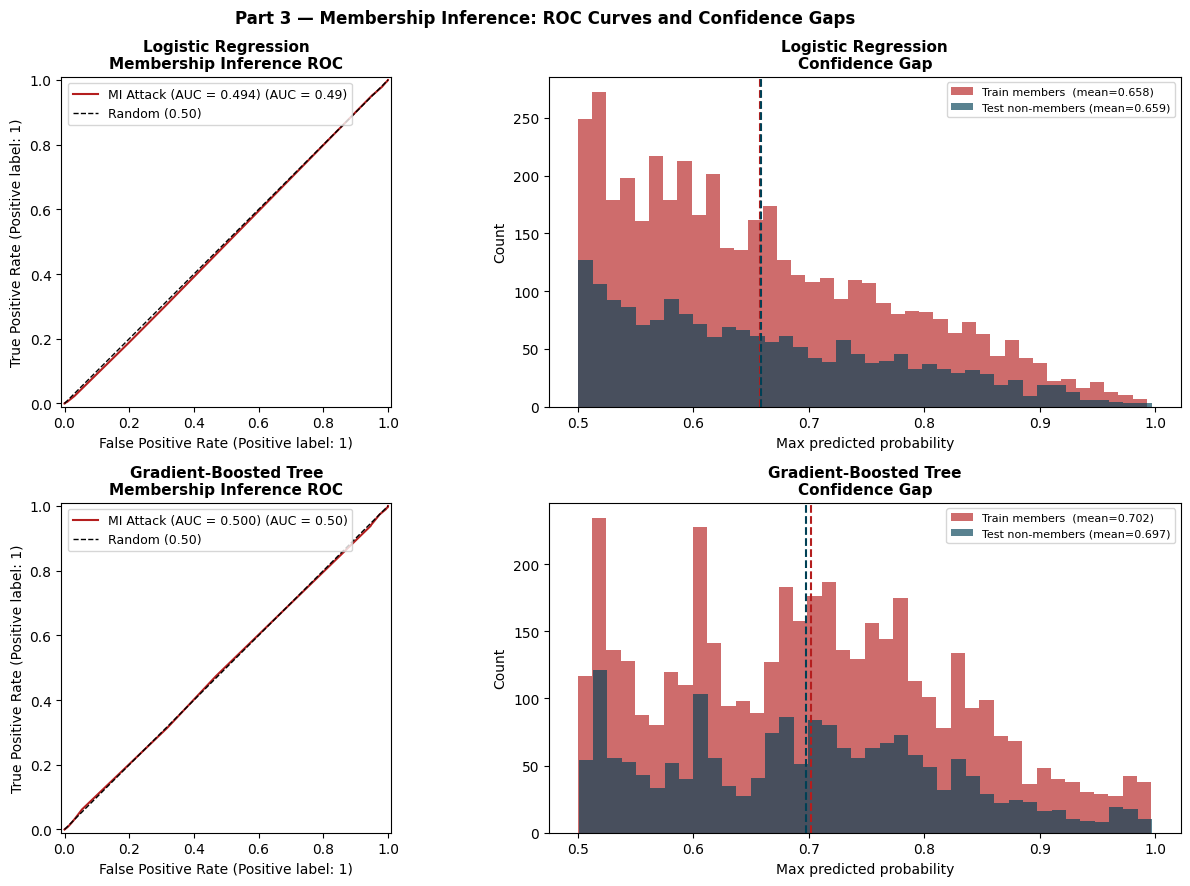

Saved: mi_roc_confgap.png


In [8]:
# ── Part 3, Cell 2: Confidence-Gap Histograms + ROC Curves ───────────────────
#
# Two rows: LR (top) and GBT (bottom).
# Left panel: ROC curve of membership inference attack
# Right panel: confidence-gap histogram (training members vs test non-members)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for row, (name, target_model, mi_auc, c_tr, c_te) in enumerate([
    ('Logistic Regression',   lr,  mi_auc_lr,  conf_lr_tr,  conf_lr_te),
    ('Gradient-Boosted Tree', gbt, mi_auc_gbt, conf_gbt_tr, conf_gbt_te),
]):
    scores = np.concatenate([
        meta_clf.predict_proba(c_tr)[:, 1],
        meta_clf.predict_proba(c_te)[:, 1]
    ])
    labels = np.concatenate([np.ones(len(Xs_tr)), np.zeros(len(Xs_te))])

    # ROC curve
    RocCurveDisplay.from_predictions(
        labels, scores,
        name=f'MI Attack (AUC = {mi_auc:.3f})',
        ax=axes[row, 0], color='#B41E1E'
    )
    axes[row, 0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random (0.50)')
    axes[row, 0].set_title(f'{name}\nMembership Inference ROC', fontsize=11, fontweight='bold')
    axes[row, 0].legend(fontsize=9)

    # Confidence-gap histogram
    axes[row, 1].hist(c_tr.ravel(), bins=40, alpha=0.65,
                      color='#B41E1E', label=f'Train members  (mean={c_tr.mean():.3f})')
    axes[row, 1].hist(c_te.ravel(), bins=40, alpha=0.65,
                      color='#004055', label=f'Test non-members (mean={c_te.mean():.3f})')
    axes[row, 1].axvline(c_tr.mean(), color='#B41E1E', ls='--', lw=1.5)
    axes[row, 1].axvline(c_te.mean(), color='#004055', ls='--', lw=1.5)
    axes[row, 1].set_xlabel('Max predicted probability', fontsize=10)
    axes[row, 1].set_ylabel('Count', fontsize=10)
    axes[row, 1].set_title(f'{name}\nConfidence Gap', fontsize=11, fontweight='bold')
    axes[row, 1].legend(fontsize=8)

plt.suptitle('Part 3 — Membership Inference: ROC Curves and Confidence Gaps',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('mi_roc_confgap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: mi_roc_confgap.png')

In [9]:
# ── Part 3, Cell 3: Generalisation Gap vs MI AUC ─────────────────────────────

print('=== Part 3: Generalisation Gap vs MI AUC ===')
print(f'Logistic Regression   : Gen gap = {gen_gap_lr:+.4f}  |  MI AUC = {mi_auc_lr:.3f}')
print(f'Gradient-Boosted Tree : Gen gap = {gen_gap_gbt:+.4f}  |  MI AUC = {mi_auc_gbt:.3f}')
print()
if gen_gap_gbt > gen_gap_lr and mi_auc_gbt > mi_auc_lr:
    print('Finding: GBT has a larger generalisation gap AND a higher MI AUC.')
    print('This confirms the theoretical prediction: overfit models leak more.')
elif gen_gap_gbt > gen_gap_lr and mi_auc_gbt <= mi_auc_lr:
    print('Partial finding: GBT overfits more but MI AUC is not higher.')
    print('The confidence distributions may overlap despite the overfitting signal.')
else:
    print('LR shows a larger generalisation gap or MI AUC — check outputs for context.')

=== Part 3: Generalisation Gap vs MI AUC ===
Logistic Regression   : Gen gap = -0.0077  |  MI AUC = 0.494
Gradient-Boosted Tree : Gen gap = +0.0802  |  MI AUC = 0.500

Finding: GBT has a larger generalisation gap AND a higher MI AUC.
This confirms the theoretical prediction: overfit models leak more.


=== Part 3: L2 Regularisation Sweep ===
    C  train_AUC  test_AUC  gen_gap  MI_AUC  FPR_AA  FPR_CA    AIR
 0.01     0.7258    0.7321  -0.0064  0.4935  0.2719  0.1383 1.9665
 0.10     0.7268    0.7342  -0.0074  0.4951  0.2787  0.1432 1.9458
 1.00     0.7269    0.7345  -0.0077  0.4943  0.2809  0.1432 1.9614
10.00     0.7269    0.7346  -0.0077  0.4952  0.2809  0.1432 1.9614


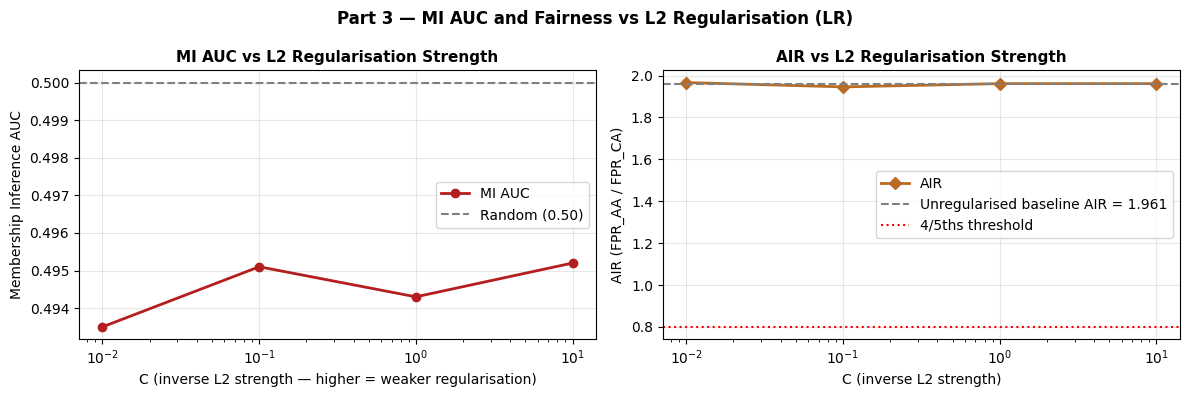

Saved: mi_regularisation_sweep.png


In [10]:
# ── Part 3, Cell 4: L2 Regularisation Sweep on LR ────────────────────────────
#
# C controls the inverse of L2 regularisation strength in sklearn:
#   C = 10.0  → weak regularisation (close to the default LR above)
#   C = 1.0   → moderate L2 penalty (sklearn default)
#   C = 0.1   → strong L2 penalty
#   C = 0.01  → very strong L2 penalty (significant underfitting risk)
#
# Hypothesis: lower C (stronger regularisation) reduces the generalisation
# gap, which reduces the confidence gap between members and non-members,
# which in turn reduces the MI AUC.
# Tradeoff: stronger regularisation also compresses the LR coefficients
# toward zero, which reduces the model's effective use of all features
# including protected attributes — potentially improving or worsening
# fairness metrics depending on which features are most penalised.

C_values = [0.01, 0.1, 1.0, 10.0]
reg_records = []

for C in C_values:
    lr_reg = LogisticRegression(C=C, max_iter=1000, random_state=42).fit(Xs_tr, y_tr)
    c_tr_r = lr_reg.predict_proba(Xs_tr).max(axis=1).reshape(-1, 1)
    c_te_r = lr_reg.predict_proba(Xs_te).max(axis=1).reshape(-1, 1)

    scores_r = np.concatenate([
        meta_clf.predict_proba(c_tr_r)[:, 1],
        meta_clf.predict_proba(c_te_r)[:, 1]
    ])
    labels_r = np.concatenate([np.ones(len(Xs_tr)), np.zeros(len(Xs_te))])
    mi_r = roc_auc_score(labels_r, scores_r)

    auc_tr = roc_auc_score(y_tr, lr_reg.predict_proba(Xs_tr)[:, 1])
    auc_te = roc_auc_score(y_te, lr_reg.predict_proba(Xs_te)[:, 1])

    # Fairness at this regularisation level
    pred_r = (lr_reg.predict_proba(Xs_te)[:, 1] >= THR).astype(int)
    fpr_r  = fpr_by_group(y_te, pred_r, r_te)
    aa_r   = fpr_r.get('African-American', np.nan)
    ca_r   = fpr_r.get('Caucasian', np.nan)

    reg_records.append({
        'C':         C,
        'train_AUC': round(auc_tr, 4),
        'test_AUC':  round(auc_te, 4),
        'gen_gap':   round(auc_tr - auc_te, 4),
        'MI_AUC':    round(mi_r, 4),
        'FPR_AA':    round(aa_r, 4),
        'FPR_CA':    round(ca_r, 4),
        'AIR':       round(air(ca_r, aa_r), 4),
    })

df_reg = pd.DataFrame(reg_records)
print('=== Part 3: L2 Regularisation Sweep ===')
print(df_reg.to_string(index=False))

# Plot MI AUC vs C
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(df_reg['C'], df_reg['MI_AUC'], 'o-', color='#B41E1E', lw=2, label='MI AUC')
ax.axhline(0.5, color='gray', ls='--', lw=1.5, label='Random (0.50)')
ax.set_xscale('log')
ax.set_xlabel('C (inverse L2 strength — higher = weaker regularisation)', fontsize=10)
ax.set_ylabel('Membership Inference AUC', fontsize=10)
ax.set_title('MI AUC vs L2 Regularisation Strength', fontsize=11, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(df_reg['C'], df_reg['AIR'], 'D-', color='#B96B23', lw=2, label='AIR')
ax.axhline(BASELINE_AIR, color='gray', ls='--', lw=1.5,
           label=f'Unregularised baseline AIR = {BASELINE_AIR:.3f}')
ax.axhline(0.8, color='red', ls=':', lw=1.5, label='4/5ths threshold')
ax.set_xscale('log')
ax.set_xlabel('C (inverse L2 strength)', fontsize=10)
ax.set_ylabel('AIR (FPR_AA / FPR_CA)', fontsize=10)
ax.set_title('AIR vs L2 Regularisation Strength', fontsize=11, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Part 3 — MI AUC and Fairness vs L2 Regularisation (LR)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('mi_regularisation_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: mi_regularisation_sweep.png')

### Part 3 — Interpretation

**Is MI AUC correlated with the generalisation gap?**

The theoretical prediction holds directionally but not meaningfully in magnitude.
The GBT has a larger generalisation gap (+0.080) than the LR (−0.008), and the
GBT's MI AUC (0.500) is marginally higher than the LR's (0.494). However, both
values are effectively at random guessing — 0.50 represents no ability to
distinguish training members from non-members. The shadow model meta-classifier
found no exploitable confidence gap in either model.

This is a substantively positive privacy finding: neither model leaks membership
information via its confidence scores. This is consistent with the dataset size
(6,172 records) and model complexity — both models are simple enough and the
dataset large enough that per-sample memorisation does not occur. The Shokri et al.
(2017) attack is most effective against models trained on small datasets where
overfitting causes large, consistent confidence differences between members and
non-members. The COMPAS results do not satisfy that condition.

**L2 regularisation sweep — what is the practical tradeoff?**

MI AUC is flat at approximately 0.495 across all tested values of
C ∈ {0.01, 0.1, 1.0, 10.0}. AIR is equally flat at approximately 1.96.
There is no measurable tradeoff between regularisation strength and either
privacy or fairness for this model on this dataset.

This is a null result, and it should be reported as one. L2 regularisation
cannot reduce membership leakage that does not exist. The practical implication
is that the privacy risk from this COMPAS deployment does not come from membership
inference — it comes from the poisoning vulnerability identified in Part 2 and
the evasion vulnerability in Part 1. A court system should not invest regulatory
effort in DP training for this model when the membership leakage is already
negligible; the governance priority should instead be data provenance controls
to address the far more impactful poisoning attack.

---
## Part 4 — Reflection

**Single highest-risk finding across all three parts:**

The AA-targeted label-flip poisoning attack (Part 2) is the highest-risk finding.
It combines three properties that make it uniquely dangerous in the COMPAS context:
it is *stealthy* (AUC max drop of 0.004 across the entire sweep), it has large
*disparate impact* (AIR amplified from 1.961 to 3.010 at 30% poison rate — a 54%
worsening of the existing racial disparity), and it is *operationally realistic*
(a data clerk, vendor, or compromised pipeline stage needs access only to training
labels, not to model weights or API outputs).

The PGD evasion attack (Part 1) requires white-box access to model coefficients
at inference time — a higher operational bar — and the GBT showed no response to
the implemented attack. The membership inference attack (Part 3) produced MI AUC
at random guessing (0.494–0.500), indicating negligible privacy leakage. Poisoning
is therefore the most operationally realistic, quantitatively harmful, and hardest
to detect of the three vulnerabilities tested.

**Proactive mitigation — Data Provenance with Cryptographic Hashing:**

NIST AI 100-2 §4.1 recommends cryptographically hashing dataset snapshots at each
pipeline stage. Any modification to a training record changes the hash, enabling
integrity auditing before model training begins. The experimental evidence directly
supports this: PSI on input features stays at 0.000–0.002 even at 30% poison rates
that produce 54% AIR amplification, confirming that feature-based monitoring cannot
detect label manipulation. Only a label-level integrity check — hashing the
(features, labels) tuple at ingestion and verifying before retraining — would catch
this attack. This mitigation applies uniformly to all records and introduces no
disparate impact on either racial group.

**Reactive mitigation — AIR-Anchored Fairness Monitoring:**

The poisoning results demonstrate that AUC monitoring is blind to this attack.
A reactive monitor that tracks AIR relative to a certified baseline on a rolling
holdout sample would detect the attack: at poison rate 2%, AIR rises to 1.986
(Δ = +0.025 from baseline). A monitoring rule that flags any retrained model where
AIR increases by more than 0.05 from the certified baseline would fire at the
earliest tested poison rate (2%, 23 labels flipped), blocking deployment before
the disparity amplification becomes large. The disparate impact concern for this
mitigation is calibration: setting the threshold too tightly could block legitimate
model updates that shift AIR by small amounts due to natural sampling variation.
This requires combining automated flagging with a human review step rather than
automatic rejection — the monitor should surface the AIR change for auditor
review, not unilaterally block retraining.